# Problem Set: Neural Networks

<span style="color:red">Warning!</span> Some problems here require training neural
networks, which can take a few minutes each

## Cars vs. Trucks: Feedforward Neural Networks

Your goal is to train **feedforward (fully-connected) neural networks** to classify
whether the vehicle in an image is a car (automobile) or a truck. We use only the
tools from lecture: tensors, `nn.Module`, activation functions, cross-entropy loss,
optimizers (SGD / Adam), the training loop, and regularization (dropout / weight
decay). No convolutions.

Use PyTorch. It may help to prototype on a small subset of the images first.

## Part I - Data

### Question 1: Load data + exploratory analysis

We'll use the [CIFAR-10](https://en.wikipedia.org/wiki/CIFAR-10) dataset, a classic
benchmark in ML. It has 10 classes; we'll use just two of them for a binary task.

Helper code to load the data is provided below.

**Your tasks:**
- Create a subset of CIFAR-10 keeping only the **automobile** and **truck** classes.
- Select 9 random images from your training subset and plot them in a 3 x 3 grid,
  each titled with its label.

In [58]:
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader, TensorDataset
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random

torch.manual_seed(42)
np.random.seed(42)

def loadCifar10(data_path):
    "load CIFAR-10 train and test datasets (pixels scaled to [0, 1])"
    transform = transforms.Compose([transforms.ToTensor()])
    cifar_train = datasets.CIFAR10(data_path, train=True, download=True, transform=transform)
    cifar_test = datasets.CIFAR10(data_path, train=False, download=True, transform=transform)
    return cifar_train, cifar_test

In [59]:
cifar_train, cifar_test = loadCifar10("./data/")
print(cifar_train.classes)

Files already downloaded and verified
Files already downloaded and verified
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [60]:
### YOUR CODE HERE
target_classes = [1, 9]

train_idx = np.where(np.isin(cifar_train.targets, target_classes))[0]
test_idx = np.where(np.isin(cifar_test.targets, target_classes))[0]

cifar_train_subset = Subset(cifar_train, train_idx)
cifar_test_subset = Subset(cifar_test, test_idx)

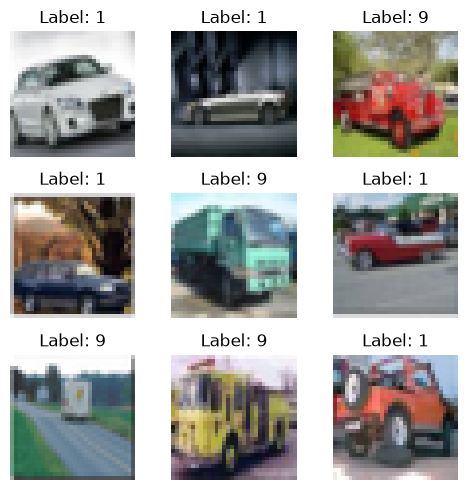

In [61]:
indices = random.sample(range(len(cifar_train_subset)), 9)
fig, axes = plt.subplots(3, 3, figsize=(5, 5))

for ax, idx in zip(axes.flatten(), indices):
    img, label = cifar_train_subset[idx]

    # Convert from (C, H, W) to (H, W, C) for matplotlib
    img = img.permute(1, 2, 0)

    ax.imshow(img)
    ax.set_title(f"Label: {label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

### Question 2: Prepare the data for a feedforward network

A feedforward network takes a flat **vector**, not a 3 x 32 x 32 image. Get the data
ready:

- Build flattened feature tensors `x_train`, `x_test` (each image becomes a length-3072
  vector) and integer label tensors `y_train`, `y_test` (0 = automobile, 1 = truck).
- Wrap them in `DataLoader`s with batch size 32 (shuffle the training loader).

**Short answer:** how many input features does each image become, and why must we
flatten the image before feeding it to a fully-connected network?

In [62]:
### YOUR CODE HERE
x_train = torch.stack([cifar_train_subset[i][0].flatten() for i in range(len(cifar_train_subset))])
x_test = torch.stack([cifar_test_subset[i][0].flatten() for i in range(len(cifar_test_subset))])

y_train = torch.stack([torch.tensor(cifar_train_subset[i][1]) for i in range(len(cifar_train_subset))])
y_test = torch.stack([torch.tensor(cifar_test_subset[i][1]) for i in range(len(cifar_test_subset))])

y_train = (y_train == 9)
y_test = (y_test == 9)

In [63]:
train_dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

In [106]:
y_train.sum()

tensor(5000)

In [109]:
y_test.sum()

tensor(1000)

*Your short answer here.*

## Part II - Neural Networks

### Question 3: Helper functions

Complete two helpers (the intro-to-PyTorch lab is a good reference):

- `trainModel`: runs the training loop and returns the list of average epoch losses.
- `validate`: given a model and a data loader, returns the **accuracy, precision,
  recall, and F1-score**.

**Note:** code the metrics **manually** (counts of true/false positives and
negatives) - do not use scikit-learn or any other library for them. Treat
truck (label 1) as the positive class.

In [76]:
def trainModel(model, n_epochs, optimizer, loss_fn, train_data_loader, test_data_loader):
    "train a regressor; return the list of average epoch losses"
    train_losses = []
    test_losses = []

    for epoch in range(n_epochs):
        model.train()
        train_loss = 0
        test_loss = 0
        
        for X, y in train_data_loader:
            y_pred = model(X) #(batch_size, 2)

            loss = loss_fn(y_pred, y.long())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        with torch.no_grad():
            for X, y in test_data_loader:
                y_pred = model(X) #(batch_size, 2)
                loss = loss_fn(y_pred, y.long())

                test_loss += loss.item()

        average_train_loss = train_loss / len(train_data_loader)
        train_losses.append(average_train_loss)
        average_test_loss = test_loss / len(test_data_loader)
        test_losses.append(average_test_loss)

        print(f"Epoch {epoch + 1}| Train loss = {average_train_loss:.4f} | Test loss = {average_test_loss:.4f}")
            
    return train_losses, test_losses
    

def validate(model, data_loader):
    "return accuracy, precision, recall, f1 (computed manually)"
    model.eval()
    tp = 0
    tn = 0
    fp = 0
    fn = 0
    
    with torch.no_grad():
        for X, y in data_loader:
            y_pred = model(X) # (batch_size, 2)
            label_pred = torch.argmax(y_pred, dim = 1) # (batch_size, )

            tp += torch.sum((y == 1) & (label_pred == 1))
            tn += torch.sum((y == 0) & (label_pred == 0))
            fp += torch.sum((y == 0) & (label_pred == 1))
            fn += torch.sum((y == 1) & (label_pred == 0))

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)

    f1 = 2 * precision * recall / (precision + recall)

    return accuracy, precision, recall, f1

### Question 4: A single-hidden-layer feedforward network

Build a feedforward network and train it.

**Architecture:**
- Input: 3072 features
- Hidden layer: 256 nodes, ReLU activation
- Output: 2 logits (one per class)

**Compile / train:**
- Loss: cross-entropy
- Optimizer: Adam
- Batch size: 32
- At least 100 epochs

Plot the average epoch loss, then report accuracy, precision, recall, and F1 on
**both** the training and test sets.

In [77]:
class FFN(nn.Module):
    def __init__(self):
        super().__init__()
        # YOUR CODE HERE
        self.layers = nn.Sequential(
            nn.Linear(3072, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        return self.layers(x)

In [78]:
loss_fn = torch.nn.CrossEntropyLoss()
model = FFN()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-4, weight_decay = 1e-4)
n_epochs = 100

train_losses, test_losses = trainModel(model, n_epochs = n_epochs, optimizer = optimizer, 
                                       loss_fn = loss_fn, 
                                       train_data_loader = train_dataloader, 
                                       test_data_loader = test_dataloader)

accuracy_train, precision_train, recall_train, f1_train = validate(model, train_dataloader)
accuracy_test, precision_test, recall_test, f1_test = validate(model, test_dataloader)

Epoch 1| Train loss = 0.6322 | Test loss = 0.6294
Epoch 2| Train loss = 0.5967 | Test loss = 0.5770
Epoch 3| Train loss = 0.5783 | Test loss = 0.5627
Epoch 4| Train loss = 0.5653 | Test loss = 0.5570
Epoch 5| Train loss = 0.5480 | Test loss = 0.5869
Epoch 6| Train loss = 0.5366 | Test loss = 0.5619
Epoch 7| Train loss = 0.5288 | Test loss = 0.5335
Epoch 8| Train loss = 0.5149 | Test loss = 0.5311
Epoch 9| Train loss = 0.5063 | Test loss = 0.5209
Epoch 10| Train loss = 0.4978 | Test loss = 0.5206
Epoch 11| Train loss = 0.4901 | Test loss = 0.5370
Epoch 12| Train loss = 0.4805 | Test loss = 0.5325
Epoch 13| Train loss = 0.4758 | Test loss = 0.5110
Epoch 14| Train loss = 0.4669 | Test loss = 0.5105
Epoch 15| Train loss = 0.4663 | Test loss = 0.5491
Epoch 16| Train loss = 0.4537 | Test loss = 0.5296
Epoch 17| Train loss = 0.4492 | Test loss = 0.5033
Epoch 18| Train loss = 0.4445 | Test loss = 0.5068
Epoch 19| Train loss = 0.4388 | Test loss = 0.5489
Epoch 20| Train loss = 0.4361 | Test los

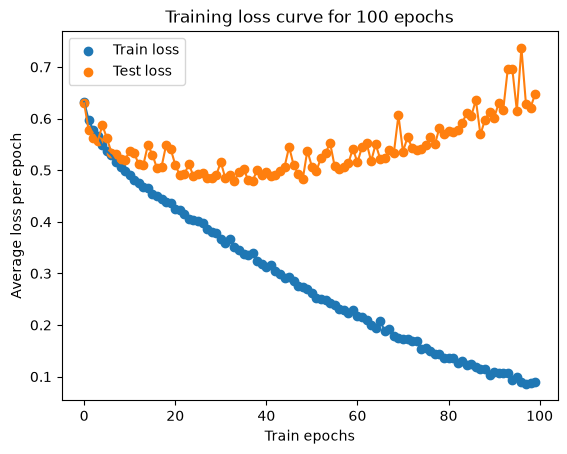

In [79]:
plt.scatter(x = np.arange(len(train_losses)), y = train_losses, label = "Train loss")
plt.scatter(x = np.arange(len(test_losses)), y = test_losses, label = "Test loss")
plt.plot(np.arange(len(train_losses)), train_losses)
plt.plot(np.arange(len(test_losses)), test_losses)

plt.xlabel("Train epochs")
plt.ylabel("Average loss per epoch")
plt.title("Training loss curve for 100 epochs")
plt.legend()

In [81]:
print(f"Train accuracy: {accuracy_train} | Train precision: {precision_train} | Train recall: {recall_train} | Train F1: {f1_train}")
print(f"Train accuracy: {accuracy_test} | Train precision: {precision_test} | Train recall: {recall_test} | Train F1: {f1_test}")

Train accuracy: 0.9793999791145325 | Train precision: 0.967616081237793 | Train recall: 0.9919999837875366 | Train F1: 0.9796563386917114
Train accuracy: 0.7795000076293945 | Train precision: 0.7710960507392883 | Train recall: 0.7950000166893005 | Train F1: 0.782865583896637


### Question 5: Your turn - build a better network

Design your own feedforward network, `NewNet`, aiming to **exceed an F1-score of
0.80** on the test set. You don't need formal cross-validation or hyperparameter
search - just experiment locally until you have an architecture that works.

Knobs you can turn (all from lecture):
- number and width of hidden layers
- activation functions (ReLU, tanh, sigmoid)
- dropout
- learning rate
- optimizer (SGD vs Adam) and weight decay
- number of epochs

(Feedforward only - no convolutions.) Train for at least 100 epochs, then report the
metrics on the train and test sets.

In [100]:
class NewNet(nn.Module):
    def __init__(self):
        super().__init__()
        # YOUR CODE HERE
        self.layers = nn.Sequential(
            nn.Linear(3072, 256),
            nn.ReLU(),
            nn.Dropout(p = 0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p = 0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p = 0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.layers(x)

In [101]:
loss_fn = torch.nn.CrossEntropyLoss()
model = NewNet()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-3, weight_decay = 1e-3)
n_epochs = 200

train_losses, test_losses = trainModel(model, n_epochs = n_epochs, optimizer = optimizer, 
                                       loss_fn = loss_fn, 
                                       train_data_loader = train_dataloader, 
                                       test_data_loader = test_dataloader)

accuracy_train, precision_train, recall_train, f1_train = validate(model, train_dataloader)
accuracy_test, precision_test, recall_test, f1_test = validate(model, test_dataloader)

Epoch 1| Train loss = 0.6478 | Test loss = 0.6117
Epoch 2| Train loss = 0.6174 | Test loss = 0.5932
Epoch 3| Train loss = 0.5959 | Test loss = 0.5773
Epoch 4| Train loss = 0.5860 | Test loss = 0.5654
Epoch 5| Train loss = 0.5795 | Test loss = 0.5515
Epoch 6| Train loss = 0.5701 | Test loss = 0.5578
Epoch 7| Train loss = 0.5621 | Test loss = 0.5564
Epoch 8| Train loss = 0.5655 | Test loss = 0.5657
Epoch 9| Train loss = 0.5559 | Test loss = 0.5480
Epoch 10| Train loss = 0.5473 | Test loss = 0.5560
Epoch 11| Train loss = 0.5409 | Test loss = 0.5562
Epoch 12| Train loss = 0.5456 | Test loss = 0.5478
Epoch 13| Train loss = 0.5381 | Test loss = 0.5432
Epoch 14| Train loss = 0.5293 | Test loss = 0.5378
Epoch 15| Train loss = 0.5308 | Test loss = 0.5563
Epoch 16| Train loss = 0.5217 | Test loss = 0.5390
Epoch 17| Train loss = 0.5214 | Test loss = 0.5265
Epoch 18| Train loss = 0.5175 | Test loss = 0.5678
Epoch 19| Train loss = 0.5164 | Test loss = 0.5352
Epoch 20| Train loss = 0.5076 | Test los

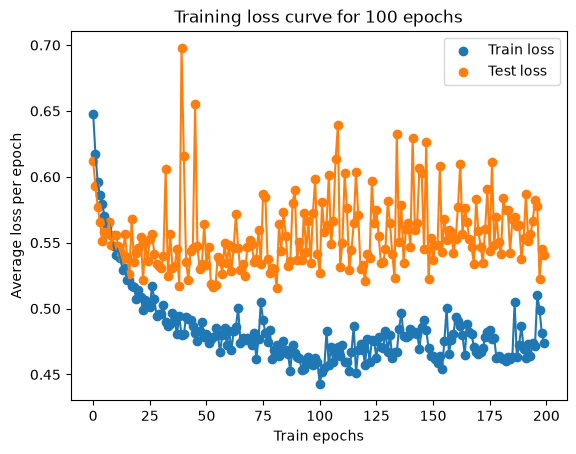

In [104]:
plt.scatter(x = np.arange(len(train_losses)), y = train_losses, label = "Train loss")
plt.scatter(x = np.arange(len(test_losses)), y = test_losses, label = "Test loss")
plt.plot(np.arange(len(train_losses)), train_losses)
plt.plot(np.arange(len(test_losses)), test_losses)

plt.xlabel("Train epochs")
plt.ylabel("Average loss per epoch")
plt.title("Training loss curve for 100 epochs")
plt.legend()

In [105]:
print(f"Train accuracy: {accuracy_train} | Train precision: {precision_train} | Train recall: {recall_train} | Train F1: {f1_train}")
print(f"Train accuracy: {accuracy_test} | Train precision: {precision_test} | Train recall: {recall_test} | Train F1: {f1_test}")

Train accuracy: 0.7932999730110168 | Train precision: 0.8068633675575256 | Train recall: 0.7712000012397766 | Train F1: 0.7886286377906799
Train accuracy: 0.7419999837875366 | Train precision: 0.7542017102241516 | Train recall: 0.7179999947547913 | Train F1: 0.7356557846069336


*(Report your best F1 here, and one sentence on what change helped most.)*

### Question 6: Overfitting and regularization

Show overfitting, then fix it.

- Train a **large** feedforward network (e.g. two wide hidden layers, no dropout) and
  record **both** train and test accuracy across epochs. You should see the train
  accuracy climb while the test accuracy stalls or drops - the train/test gap is
  overfitting.
- Now train a network of the **same capacity** but with a regularizer from lecture
  (dropout and/or weight decay). Show that the train/test gap shrinks.
- **Short answer:** what is overfitting, and why does your chosen fix help?

In [ ]:
### YOUR CODE HERE


*Your short answer here.*

### Extra credit (optional): SGD vs Adam

Train the single-hidden-layer `FFN` twice - once with `SGD` and once with `Adam`
(same learning rate) - and plot the two training-loss curves on the same axes.
Which converges faster here?

In [ ]:
### YOUR CODE HERE
